In [1]:
import helpers as h
import pandas as pd
import torch
import os, sys
import matplotlib.pyplot as plt
# sys.path.append(os.getcwd())
sys.path.append(f"{os.getcwd()}/..")

from wifiplotting import TL_CORNER, BR_CORNER

# constrct APObs

In [2]:
sequoia_df = pd.read_csv("../../data/sequoia.csv", index_col="index").reset_index(drop=True)

In [3]:
sequoia_df.head()

,date,time_pdt,latitude,longitude,indoor,ap,floor,rssi_set,rssi_sample,rssi_signal_measured,rssi_n_valid,noise_set,noise_sample,noise_n_valid,noise_signal_measured,timestamp,location_timestamp,mid
0,2026-04-27,17:11:02.508330,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:02.508330-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0
1,2026-04-27,17:11:03.719977,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:03.719977-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0
2,2026-04-27,17:11:04.951550,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:04.951550-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0
3,2026-04-27,17:11:07.470753,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:07.470753-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a
4,2026-04-27,17:11:08.676819,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-44.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:08.676819-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a


In [4]:
ref_point = [BR_CORNER[0], TL_CORNER[1]]
print(ref_point[1], sequoia_df['longitude'].min())
print(ref_point[0], sequoia_df['latitude'].min())

assert ref_point[1] <= sequoia_df['longitude'].min(), ref_point[0] <= sequoia_df['latitude'].min()
converted_lats_lons = h.lonlat_to_north_east(
    points = zip(sequoia_df['longitude'], sequoia_df['latitude']),
    reference = [ref_point[1], ref_point[0]]
)

-122.173904 -122.1738972376479
37.42705 37.42705202003412


In [5]:
sequoia_df['north_m'], sequoia_df['east_m'] = list(zip(*converted_lats_lons))

In [6]:
sequoia_df = sequoia_df[
    ~sequoia_df['ap'].str.contains("failed") 
    & sequoia_df['rssi_sample'].notna()
]

In [7]:
ap_uniq_locs = sequoia_df.assign(
    tup = [(a, b) for a, b in zip(sequoia_df['north_m'], sequoia_df['east_m'])]
).groupby('ap')['tup'].nunique()
big_aps= ap_uniq_locs[ap_uniq_locs >= 8]

In [8]:
sequoia_df[sequoia_df['ap'].isin(big_aps.index)].shape

(4753, 20)

In [9]:
special_ap = "5c:5a:c7:10:01:4e"

In [10]:
ap_obs_list = []
for ap_name, group in sequoia_df.groupby('ap'):
    # if ap_name != special_ap:
    #     continue
    ap_obs_list.append(
        h.APObs(
            ap_id=ap_name,
            xy=torch.tensor([
                group['north_m'].to_list(),
                group['east_m'].to_list(),
            ]).T,
            y=torch.tensor(group['rssi_sample'].to_list()),
            outdoor=torch.tensor((~group['indoor']).to_numpy().astype(int)),
        )
    )

In [11]:
dense_ap_data = [
    ap for ap in ap_obs_list
    if h.keep_for_dense_sse_baseline(
        ap,
        min_unique_locations=8,
        tol_m=1.0,
    )
]

In [12]:
device = h.choose_device(prefer_mps=True)
device

device(type='mps')

In [13]:
sse_model = h.DenseAPSSEEstimator(
    ap_data=dense_ap_data,
    min_obs=10,
    learn_gamma=True,
    shared_gamma=False,
    device=device,
)

In [14]:
len(ap_obs_list)

317

In [15]:
sse_model.loss()

tensor(292724.7188, device='mps:0', grad_fn=<AddBackward0>)

In [16]:
# a = 4
# self = sse_model
# ap = self.ap_data[a]

# b = self.b[a]
# w = torch.exp(self.log_w[a])
# ell = torch.exp(self.log_ell[a])
# mu = self.mu[a]
# gamma = self.gamma

# d2 = (ap.xy - mu[None, :]).pow(2).sum(dim=1).clip(0, ell.detach() ** 2 * 1)
# print(d2)

# kernel = torch.exp(
#     -0.5 * d2 / ell.pow(2)
#     - gamma * ap.outdoor
# )

# b + w * kernel

In [17]:
# total = torch.zeros((), device=sse_model.device, dtype=sse_model.dtype)

# for a, ap in enumerate(sse_model.ap_data):
#     pred = sse_model.predict_ap(a)
#     resid = ap.y - pred
#     if torch.isnan(pred).any() or torch.isnan(resid).any():
#         print(ap.ap_id)
#         print(pred)
#         print(ap.y)
#         print(resid)
#     # print(resid.pow(2).sum())
#     # total = total + resid.pow(2).sum()

In [18]:
# Adam warm start
loss_log = h.fit_torch_module(
    sse_model,
    steps=6000,
    lr=1e-2,
    optimizer_name="adam",
    print_every=250,
)

[Adam] step=00000 loss=292724.7188
[Adam] step=00250 loss=168369.3438
[Adam] step=00500 loss=159436.6562
[Adam] step=00750 loss=154903.2656
[Adam] step=01000 loss=152753.5469
[Adam] step=01250 loss=151337.7500
[Adam] step=01500 loss=150387.6406
[Adam] step=01750 loss=149617.6875
[Adam] step=02000 loss=149035.1250
[Adam] step=02250 loss=148553.7344
[Adam] step=02500 loss=148205.4844
[Adam] step=02750 loss=147703.6875
[Adam] step=03000 loss=146781.4062
[Adam] step=03250 loss=146379.2500
[Adam] step=03500 loss=146050.9375
[Adam] step=03750 loss=145772.4844
[Adam] step=04000 loss=145541.3906
[Adam] step=04250 loss=145349.3125
[Adam] step=04500 loss=145205.1562
[Adam] step=04750 loss=145077.5156
[Adam] step=05000 loss=144959.7188
[Adam] step=05250 loss=144854.3594
[Adam] step=05500 loss=144752.6875
[Adam] step=05750 loss=144659.2969


In [19]:
# Optional LBFGS polish
h.fit_torch_module(
    sse_model,
    steps=1000,
    lr=0.5,
    optimizer_name="lbfgs",
)

[LBFGS] final loss=144571.0781


[144571.078125]

In [20]:
sum([len(ap.y) for ap in sse_model.ap_data])

4678

In [21]:
sse_summary = sse_model.summary()

In [22]:
sse_summary['gamma']

[0.2329902946949005,
 0.022858642041683197,
 0.123406320810318,
 0.2849498689174652,
 0.3251863121986389,
 0.25605645775794983,
 0.16816207766532898,
 1.534824252128601,
 0.21814224123954773,
 0.7616714239120483,
 0.23518939316272736,
 0.3954576253890991,
 0.0997789204120636,
 0.2007751613855362,
 0.25394025444984436,
 0.18925851583480835,
 0.21306709945201874,
 0.1998624950647354,
 2.483009099960327,
 0.10528957098722458,
 0.18165351450443268,
 0.2471114546060562,
 0.3105340600013733,
 0.48516368865966797,
 3.340325117111206,
 0.2359030842781067,
 0.500001072883606,
 0.10661187022924423,
 0.39195531606674194,
 0.3978961110115051,
 0.21631164848804474,
 0.19042028486728668,
 0.372043639421463,
 0.09437551349401474,
 0.22153355181217194,
 0.04121403768658638,
 0.28434014320373535,
 0.17223365604877472,
 0.06703025102615356,
 0.3233073949813843,
 0.3275119960308075,
 0.33466216921806335,
 0.7361623644828796,
 0.31782782077789307,
 1.6542640924453735,
 0.8387709856033325,
 0.2445312440395

In [23]:
sequoia_df.groupby("ap")['date'].count().sort_values(ascending=False).head()

ap
64:3a:ea:93:ec:6e    258
5c:5a:c7:10:01:4e    204
64:3a:ea:93:fc:0e    174
a0:3d:6f:98:06:0d    138
a8:3a:79:c7:75:12    126
Name: date, dtype: int64

In [24]:
special_ap = "a8:3a:79:c4:5f:52"
idx = [i for i, ap in enumerate(sse_model.ap_data) if ap.ap_id == special_ap][0]

In [25]:
with torch.no_grad():
    l = sse_model.predict_ap(idx)


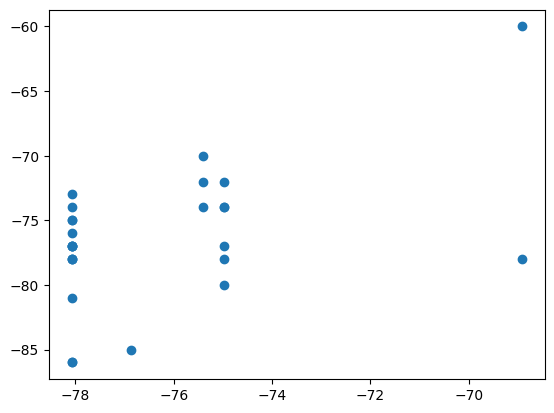

In [26]:
plt.scatter(l.cpu(), sse_model.ap_data[idx].y.cpu())

# viz

In [27]:
import wifiplotting as wp
import numpy as np

In [39]:
osm_context = wp.OSMPlotContext.from_bounds(
    init_lons=[BR_CORNER[1], TL_CORNER[1]],
    init_lats=[BR_CORNER[0], TL_CORNER[0]],
)

plot_df = sequoia_df.dropna(subset=["latitude", "longitude", "rssi_sample", "indoor"]).copy()
plot_df["indoor_label"] = np.where(plot_df["indoor"].astype(bool), "Indoor", "Outdoor")

lat_bounds = (osm_context.bounds[1], osm_context.bounds[3])
lon_bounds = (osm_context.bounds[0], osm_context.bounds[2])

print(f"Using {len(plot_df):,} non-null RSSI observations from {len(sequoia_df):,} rows.")

Using 7,775 non-null RSSI observations from 7,775 rows.


In [40]:
in_lats = np.linspace(BR_CORNER[0], TL_CORNER[0], 100)
in_lons = np.linspace(BR_CORNER[1], TL_CORNER[1], 100)[::-1]

in_pts_lats, in_pts_lons = (lambda v: (v[0].ravel(), v[1].ravel()))(np.meshgrid(in_lats, in_lons))

in_world_pts = osm_context.to_world(lon=in_pts_lons, lat=in_pts_lats)
is_out = np.zeros(len(in_pts_lons)).astype(np.float32) 
# is_out =  ~(osm_context.contains_building(lon=in_pts_lons, lat=in_pts_lats))

In [41]:
is_out.mean(), sse_summary['gamma']

(np.float32(0.0),
 [0.2329902946949005,
  0.022858642041683197,
  0.123406320810318,
  0.2849498689174652,
  0.3251863121986389,
  0.25605645775794983,
  0.16816207766532898,
  1.534824252128601,
  0.21814224123954773,
  0.7616714239120483,
  0.23518939316272736,
  0.3954576253890991,
  0.0997789204120636,
  0.2007751613855362,
  0.25394025444984436,
  0.18925851583480835,
  0.21306709945201874,
  0.1998624950647354,
  2.483009099960327,
  0.10528957098722458,
  0.18165351450443268,
  0.2471114546060562,
  0.3105340600013733,
  0.48516368865966797,
  3.340325117111206,
  0.2359030842781067,
  0.500001072883606,
  0.10661187022924423,
  0.39195531606674194,
  0.3978961110115051,
  0.21631164848804474,
  0.19042028486728668,
  0.372043639421463,
  0.09437551349401474,
  0.22153355181217194,
  0.04121403768658638,
  0.28434014320373535,
  0.17223365604877472,
  0.06703025102615356,
  0.3233073949813843,
  0.3275119960308075,
  0.33466216921806335,
  0.7361623644828796,
  0.317827820777893

In [42]:
meter_pts = h.lonlat_to_north_east(
    points = list(zip(in_pts_lons, in_pts_lats)),
    reference=ref_point[::-1]
)

In [43]:
with torch.no_grad():
    predictions = sse_model.predict_points(
        a = idx, xy = torch.tensor(meter_pts).to("mps"), outdoor = torch.tensor(is_out).to("mps")
    ).detach().cpu().numpy()
    print(predictions.mean() - sse_model.b[idx]) # -71.637634 (0.0517) # -71.63964 ( 0.0497 )

tensor(45.5644, device='mps:0')


In [44]:
sse_model.b[idx], torch.exp(sse_model.log_w[idx])

(tensor(-83.0684, device='mps:0', grad_fn=<SelectBackward0>),
 tensor(113246.6406, device='mps:0', grad_fn=<ExpBackward0>))

In [45]:
# inverse transform the mu coordinates
mu_lon_lat = h.north_east_to_lonlat(
    [sse_model.mu[idx].detach().cpu().numpy()],# [::-1],
    reference=ref_point[::-1],
)[0]

In [46]:
mu_w_lon_lat = osm_context.to_world(
    lon=mu_lon_lat[0],
    lat=mu_lon_lat[1]
)

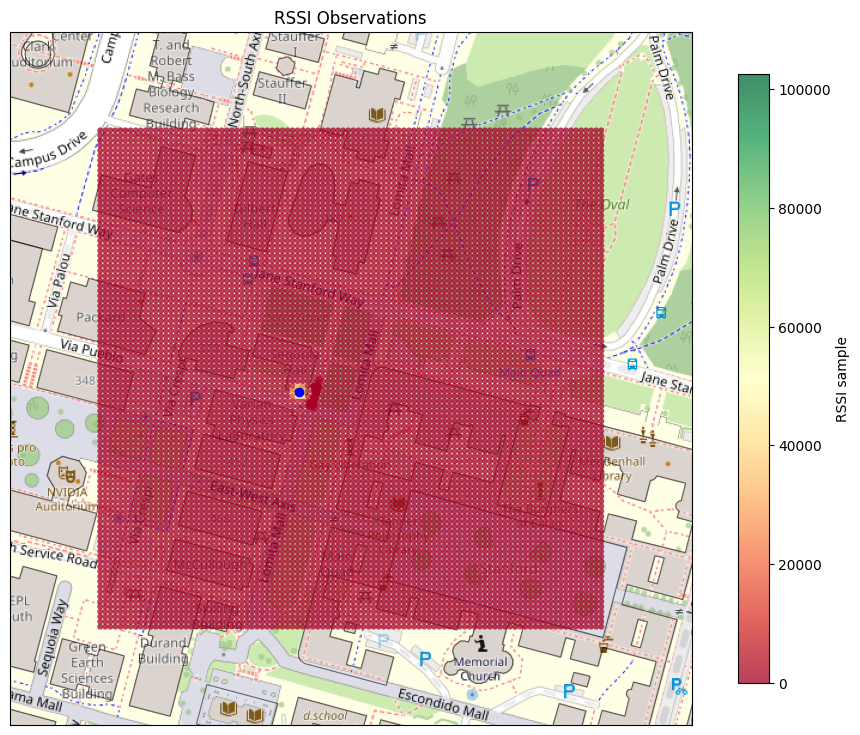

In [47]:
fig, ax, osm_metadata = osm_context.generate_base_axis(figsize=(12, 9))
curr_df = plot_df[plot_df['ap'] == special_ap]

x, y = osm_context.to_world(
    curr_df["longitude"].to_numpy(), curr_df["latitude"].to_numpy())

vmin = min(np.min(predictions), curr_df['rssi_sample'].min())
vmax = max(np.max(predictions), curr_df['rssi_sample'].max())

model_pts = ax.scatter(
    in_world_pts[0],
    in_world_pts[1],
    c=predictions,
    cmap="RdYlGn",
    s=18,
    alpha=0.75,
    edgecolors="none",
    zorder=3,
    vmin=vmin,
    vmax=vmax
)

points = ax.scatter(
    x,
    y,
    c=curr_df["rssi_sample"],
    cmap="RdYlGn",
    s=36,
    alpha=0.75,
    edgecolors="none",
    zorder=3,
    vmin=vmin,
    vmax=vmax
)

mu_viz = ax.scatter(
    mu_w_lon_lat[0],
    mu_w_lon_lat[1],
    color='b',
    zorder=100
)

# colorbar = fig.colorbar(model_pts, ax=ax, shrink=0.88)
colorbar = fig.colorbar(points, ax=ax, shrink=0.88)
colorbar.set_label("RSSI sample")
ax.set_title("RSSI Observations")
plt.show()

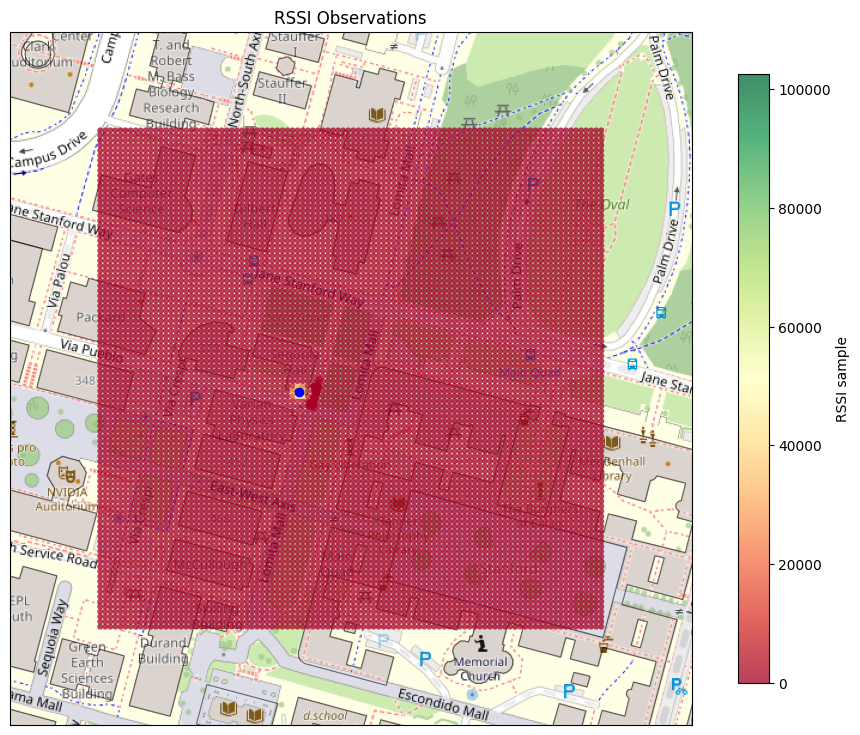

In [48]:
fig, ax, osm_metadata = osm_context.generate_base_axis(figsize=(12, 9))
curr_df = plot_df[plot_df['ap'] == special_ap]

x, y = osm_context.to_world(
    curr_df["longitude"].to_numpy(), curr_df["latitude"].to_numpy())

vmin = min(np.min(predictions), curr_df['rssi_sample'].min())
vmax = max(np.max(predictions), curr_df['rssi_sample'].max())

model_pts = ax.scatter(
    in_world_pts[0],
    in_world_pts[1],
    c=predictions,
    cmap="RdYlGn",
    s=18,
    alpha=0.75,
    edgecolors="none",
    zorder=3,
    vmin=vmin,
    vmax=vmax
)

points = ax.scatter(
    x,
    y,
    c=curr_df["rssi_sample"],
    cmap="RdYlGn",
    s=36,
    alpha=0.75,
    edgecolors="none",
    zorder=3,
    vmin=vmin,
    vmax=vmax
)

mu_viz = ax.scatter(
    mu_w_lon_lat[0],
    mu_w_lon_lat[1],
    color='b',
    zorder=100
)

# colorbar = fig.colorbar(model_pts, ax=ax, shrink=0.88)
colorbar = fig.colorbar(points, ax=ax, shrink=0.88)
colorbar.set_label("RSSI sample")
ax.set_title("RSSI Observations")
plt.show()

# winning AP grid

In [49]:
def predict_all_access_points_on_grid(model, meter_pts, outdoor, chunk_size=4096):
    """Evaluate every fitted AP surface on the supplied grid."""
    device = model.device
    dtype = model.dtype
    xy_all = torch.as_tensor(np.asarray(meter_pts), device=device, dtype=dtype)
    outdoor_all = torch.as_tensor(np.asarray(outdoor), device=device, dtype=dtype)

    pred_chunks = []
    with torch.no_grad():
        for start in range(0, xy_all.shape[0], chunk_size):
            stop = min(start + chunk_size, xy_all.shape[0])
            xy_chunk = xy_all[start:stop]
            outdoor_chunk = outdoor_all[start:stop]
            chunk_preds = [
                model.predict_points(a=a, xy=xy_chunk, outdoor=outdoor_chunk)
                for a in range(model.A)
            ]
            pred_chunks.append(torch.stack(chunk_preds, dim=1).detach().cpu())

    return torch.cat(pred_chunks, dim=0).numpy()


all_ap_predictions = predict_all_access_points_on_grid(
    sse_model,
    meter_pts=meter_pts,
    outdoor=is_out,
)
winning_ap_idx = np.argmax(all_ap_predictions, axis=1)
winning_ap_ids = np.array(sse_model.ap_ids)[winning_ap_idx]
winning_rssi = all_ap_predictions[np.arange(all_ap_predictions.shape[0]), winning_ap_idx]

winner_counts = (
    pd.Series(winning_ap_ids, name="winning_ap")
    .value_counts()
    .rename_axis("ap")
    .reset_index(name="grid_points_won")
)

all_ap_predictions.shape, winner_counts.head()

((10000, 81),
                   ap  grid_points_won
 0  70:db:98:2c:f2:1e             6579
 1  a0:b4:39:78:a6:ee              318
 2  64:3a:ea:93:ec:6e              276
 3  04:cd:c0:06:b2:52              271
 4  a8:3a:79:c7:75:12              242)

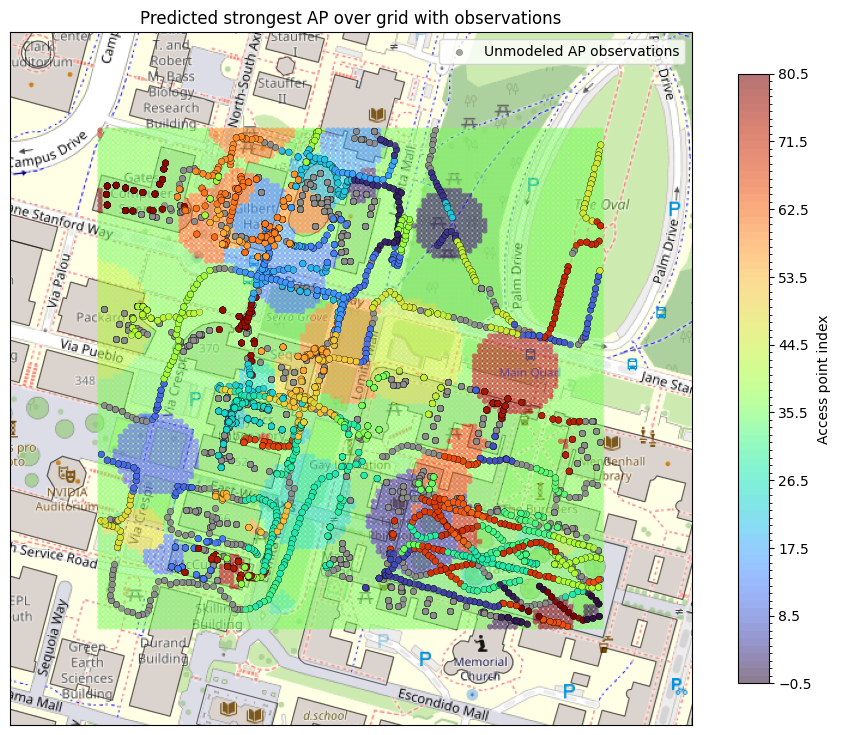

,ap,grid_points_won
0,70:db:98:2c:f2:1e,6579
1,a0:b4:39:78:a6:ee,318
2,64:3a:ea:93:ec:6e,276
3,04:cd:c0:06:b2:52,271
4,a8:3a:79:c7:75:12,242
5,bc:26:c7:71:89:ae,241
6,3c:51:0e:f9:93:8e,217
7,a0:3d:6f:98:06:0d,194
8,00:f6:63:28:19:01,159
9,54:33:c6:b6:47:62,149


In [50]:
import matplotlib.colors as mcolors

ap_ids = np.array(sse_model.ap_ids)
ap_to_idx = {ap_id: i for i, ap_id in enumerate(ap_ids)}
modeled_ap_ids = set(ap_ids)
n_aps = len(ap_ids)

modeled_obs = plot_df[plot_df["ap"].isin(modeled_ap_ids)].copy()
unmodeled_obs = plot_df[~plot_df["ap"].isin(modeled_ap_ids)].copy()
modeled_obs_idx = modeled_obs["ap"].map(ap_to_idx).astype(int).to_numpy()

cmap = plt.get_cmap("tab20" if n_aps <= 20 else "turbo", n_aps)
norm = mcolors.BoundaryNorm(np.arange(-0.5, n_aps + 0.5), n_aps)

fig, ax, osm_metadata = osm_context.generate_base_axis(figsize=(12, 9))

winner_pts = ax.scatter(
    in_world_pts[0],
    in_world_pts[1],
    c=winning_ap_idx,
    cmap=cmap,
    norm=norm,
    s=18,
    alpha=0.55,
    edgecolors="none",
    zorder=3,
)

if len(unmodeled_obs) > 0:
    unmodeled_x, unmodeled_y = osm_context.to_world(
        unmodeled_obs["longitude"].to_numpy(),
        unmodeled_obs["latitude"].to_numpy(),
    )
    ax.scatter(
        unmodeled_x,
        unmodeled_y,
        color="0.55",
        s=20,
        alpha=0.8,
        edgecolors="black",
        linewidths=0.2,
        label="Unmodeled AP observations",
        zorder=4,
    )

obs_x, obs_y = osm_context.to_world(
    modeled_obs["longitude"].to_numpy(),
    modeled_obs["latitude"].to_numpy(),
)
obs_pts = ax.scatter(
    obs_x,
    obs_y,
    c=modeled_obs_idx,
    cmap=cmap,
    norm=norm,
    s=22,
    alpha=0.9,
    edgecolors="black",
    linewidths=0.2,
    zorder=5,
)

colorbar = fig.colorbar(winner_pts, ax=ax, shrink=0.88)
if n_aps <= 25:
    colorbar.set_ticks(np.arange(n_aps))
    colorbar.set_ticklabels(ap_ids)
    colorbar.set_label("Access point")
else:
    colorbar.set_label("Access point index")

if len(unmodeled_obs) > 0:
    ax.legend(loc="upper right")

ax.set_title("Predicted strongest AP over grid with observations")
plt.show()

winner_counts.head(10)

# argmax diagnostics

In [ ]:
problem_ap = "70:db:98:2c:f2:1e"


def diagnose_argmax_ap(model, ap_id, grid_predictions, winner_idx, plot_df, meter_pts):
    a = model.ap_ids.index(ap_id)
    ap = model.ap_data[a]
    grid_pred = grid_predictions[:, a]
    obs_pred = model.predict_ap(a).detach().cpu().numpy()
    obs_y = ap.y.detach().cpu().numpy()
    obs_xy = ap.xy.detach().cpu().numpy()
    mu = model.mu[a].detach().cpu().numpy()
    grid_xy = np.asarray(meter_pts)

    ap_rows = plot_df[plot_df["ap"] == ap_id]
    nearest_grid_to_mu_m = np.sqrt(((grid_xy - mu) ** 2).sum(axis=1)).min()
    nearest_obs_to_mu_m = np.sqrt(((obs_xy - mu) ** 2).sum(axis=1)).min()

    return pd.Series(
        {
            "ap": ap_id,
            "model_index": a,
            "grid_points_won": int((winner_idx == a).sum()),
            "n_obs_model": len(obs_y),
            "n_obs_plot_df": len(ap_rows),
            "n_unique_locations_1m": h.num_unique_locations(ap.xy, ap.y, tol_m=1.0),
            "obs_rssi_min": float(np.nanmin(obs_y)),
            "obs_rssi_mean": float(np.nanmean(obs_y)),
            "obs_rssi_max": float(np.nanmax(obs_y)),
            "fitted_on_obs_min": float(np.nanmin(obs_pred)),
            "fitted_on_obs_mean": float(np.nanmean(obs_pred)),
            "fitted_on_obs_max": float(np.nanmax(obs_pred)),
            "grid_pred_min": float(np.nanmin(grid_pred)),
            "grid_pred_mean": float(np.nanmean(grid_pred)),
            "grid_pred_max": float(np.nanmax(grid_pred)),
            "b": float(model.b[a].detach().cpu()),
            "w": float(torch.exp(model.log_w[a]).detach().cpu()),
            "ell_m": float(torch.exp(model.log_ell[a]).detach().cpu()),
            "mu_north_m": float(mu[0]),
            "mu_east_m": float(mu[1]),
            "nearest_grid_to_mu_m": float(nearest_grid_to_mu_m),
            "nearest_obs_to_mu_m": float(nearest_obs_to_mu_m),
            "gamma": float(model.gamma.detach().cpu()),
        }
    )


problem_ap_diagnostics = diagnose_argmax_ap(
    sse_model,
    problem_ap,
    all_ap_predictions,
    winning_ap_idx,
    plot_df,
    meter_pts,
)

problem_ap_diagnostics


ValueError: only one element tensors can be converted to Python scalars

In [ ]:
ap_grid_diagnostics = pd.DataFrame(
    [
        {
            "ap": ap_id,
            "grid_points_won": int((winning_ap_idx == a).sum()),
            "grid_pred_max": float(np.nanmax(all_ap_predictions[:, a])),
            "grid_pred_mean": float(np.nanmean(all_ap_predictions[:, a])),
            "b": float(sse_model.b[a].detach().cpu()),
            "w": float(torch.exp(sse_model.log_w[a]).detach().cpu()),
            "ell_m": float(torch.exp(sse_model.log_ell[a]).detach().cpu()),
            "n_obs": len(sse_model.ap_data[a].y),
        }
        for a, ap_id in enumerate(sse_model.ap_ids)
    ]
)

ap_grid_diagnostics.sort_values(
    ["grid_pred_max", "grid_points_won"],
    ascending=False,
).head(15)


,ap,grid_points_won,grid_pred_max,grid_pred_mean,b,w,ell_m,n_obs
50,a8:3a:79:c4:5f:52,29,102626.914062,-37.504005,-83.068413,113246.640625,3.008729,27
1,00:6b:f1:9c:23:fe,11,5547.764160,-76.839348,-78.890678,13282.576172,3.367228,28
38,7c:ad:4f:67:6b:ae,7,2019.184326,-73.058350,-73.471664,2338.490234,1.784156,48
48,a8:3a:79:7d:9b:22,59,214.279968,-77.260704,-77.890327,309.185699,7.105834,27
75,bc:26:c7:71:89:ae,241,145.665466,-67.962997,-69.504082,215.229843,13.432681,69
19,54:33:c6:c6:79:c2,1,119.524857,-75.764252,-75.798569,321.082794,0.963684,21
44,a0:b4:39:78:a6:ee,318,99.326889,-88.596848,-92.111191,192.402618,21.496044,78
27,5c:5a:c7:25:89:2e,29,47.405907,-84.105812,-84.336906,145.038986,6.265539,15
37,70:db:98:33:49:7e,1,35.063095,-76.917183,-76.937607,115.571831,1.758372,18
33,70:70:8b:84:64:8e,7,20.667419,-86.724838,-86.783134,128.935532,3.211815,27


# winning AP fitted RSSI surface

In [ ]:
vmax

np.float32(102626.914)

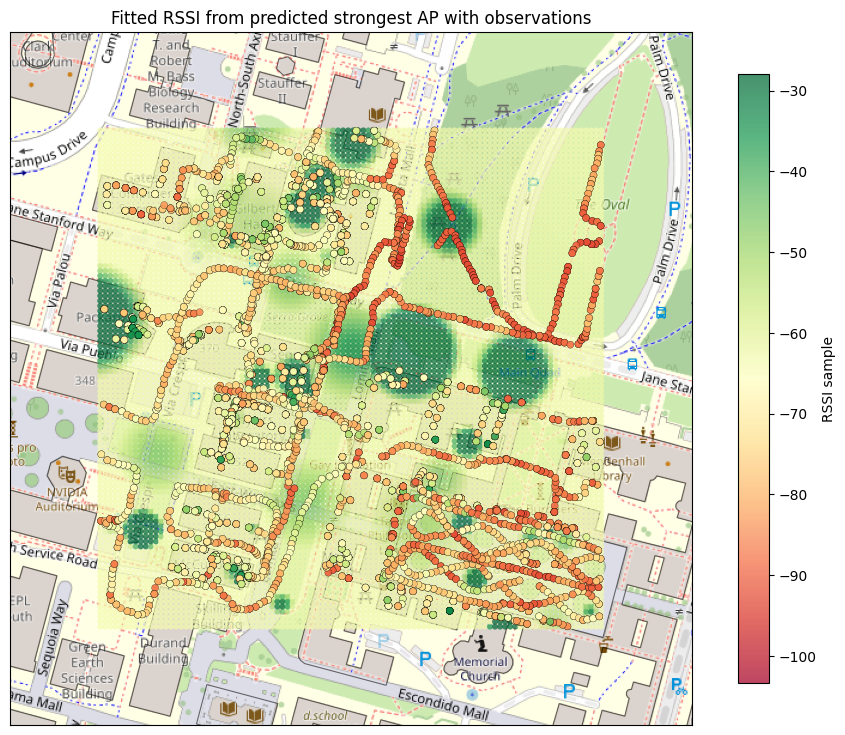

In [ ]:
obs_x, obs_y = osm_context.to_world(
    plot_df["longitude"].to_numpy(),
    plot_df["latitude"].to_numpy(),
)

# vmin = min(np.nanmin(winning_rssi), plot_df["rssi_sample"].min())
vmin = min([plot_df["rssi_sample"].min() * 1.1])
# vmax = max(np.nanmax(winning_rssi), plot_df["rssi_sample"].max())
vmax = max([plot_df["rssi_sample"].max() * 0.9])

fig, ax, osm_metadata = osm_context.generate_base_axis(figsize=(12, 9))

surface_pts = ax.scatter(
    in_world_pts[0],
    in_world_pts[1],
    c=winning_rssi,
    cmap="RdYlGn",
    s=18,
    alpha=0.72,
    edgecolors="none",
    vmin=vmin,
    vmax=vmax,
    zorder=3,
)

obs_pts = ax.scatter(
    obs_x,
    obs_y,
    c=plot_df["rssi_sample"],
    cmap="RdYlGn",
    s=26,
    alpha=0.9,
    edgecolors="black",
    linewidths=0.2,
    vmin=vmin,
    vmax=vmax,
    zorder=5,
)

colorbar = fig.colorbar(surface_pts, ax=ax, shrink=0.88)
colorbar.set_label("RSSI sample")

ax.set_title("Fitted RSSI from predicted strongest AP with observations")
plt.show()


# train test split

In [ ]:
def ap_train_test_split(df, train_frac=0.8, group_col="ap", random_state=305):
    # Shuffle rows, then take train_frac from each AP group for training.
    if not 0 <= train_frac <= 1:
        raise ValueError("train_frac must be between 0 and 1.")

    rng = np.random.default_rng(random_state)
    split_df = (
        df.assign(_split_rand=rng.random(len(df)))
        .sort_values("_split_rand")
        .copy()
    )

    groups = split_df.groupby(group_col, sort=False, dropna=False)
    group_rank = groups.cumcount() + 1
    group_count = groups[group_col].transform("size")
    train_cutoff = np.floor(group_count * train_frac).astype(int)

    train_mask = group_rank <= train_cutoff
    train_df = split_df.loc[train_mask].drop(columns="_split_rand").copy()
    test_df = split_df.loc[~train_mask].drop(columns="_split_rand").copy()

    return train_df, test_df


train_df, test_df = ap_train_test_split(sequoia_df, train_frac=0.8, random_state=305)
train_df.shape, test_df.shape


In [ ]:
ap_obs_list = []
for ap_name, group in train_df.groupby('ap'):
    ap_obs_list.append(
        h.APObs(
            ap_id=ap_name,
            xy=torch.tensor([
                group['north_m'].to_list(),
                group['east_m'].to_list(),
            ]).T,
            y=torch.tensor(group['rssi_sample'].to_list()),
            outdoor=torch.tensor((~group['indoor']).to_numpy().astype(int)),
        )
    )

In [ ]:
test_ap_obs_dict = {}
for ap_name, group in test_df.groupby('ap'):
    test_ap_obs_dict[ap_name] = h.APObs(
        ap_id=ap_name,
        xy=torch.tensor([
            group['north_m'].to_list(),
            group['east_m'].to_list(),
        ]).T,
        y=torch.tensor(group['rssi_sample'].to_list()),
        outdoor=torch.tensor((~group['indoor']).to_numpy().astype(int)),
    )

In [ ]:
dense_ap_data = [
    ap for ap in ap_obs_list
    if h.keep_for_dense_sse_baseline(
        ap,
        min_unique_locations=8,
        tol_m=1.0,
    )
]

In [ ]:
test_dense_ap_data = [
    test_ap_obs_dict[ap.ap_id]
    for ap in dense_ap_data
]

In [ ]:
sequoia_df[sequoia_df['ap'].isin(set(ap.ap_id for ap in dense_ap_data))].shape, train_df[train_df['ap'].isin(set(ap.ap_id for ap in dense_ap_data))].shape

## KNN baselines

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

dense_ap_ids = {ap.ap_id for ap in dense_ap_data}
knn_feature_cols = ["latitude", "longitude", "indoor"]
target_col = "rssi_sample"

knn_train_df = (
    train_df[train_df["ap"].isin(dense_ap_ids)]
    .dropna(subset=[*knn_feature_cols, target_col])
    .copy()
)
knn_test_df = (
    test_df[test_df["ap"].isin(dense_ap_ids)]
    .dropna(subset=[*knn_feature_cols, target_col])
    .copy()
)

knn_train_df["indoor"] = knn_train_df["indoor"].astype(float)
knn_test_df["indoor"] = knn_test_df["indoor"].astype(float)

knn_train_df.shape, knn_test_df.shape

## knn baseline

In [ ]:
global_knn_k = min(25, len(knn_train_df))
global_knn = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=global_knn_k, weights="distance"),
)

global_knn.fit(knn_train_df[knn_feature_cols], knn_train_df[target_col])
knn_test_df["global_knn_pred"] = global_knn.predict(knn_test_df[knn_feature_cols])

global_knn_mse = mean_squared_error(
    knn_test_df[target_col],
    knn_test_df["global_knn_pred"],
)

global_knn_mse

In [ ]:
per_ap_knn_k = 10
per_ap_predictions = []

for ap_id, train_group in knn_train_df.groupby("ap"):
    test_group = knn_test_df[knn_test_df["ap"] == ap_id]
    if test_group.empty:
        continue

    n_neighbors = min(per_ap_knn_k, len(train_group))
    if n_neighbors == 0:
        continue

    ap_knn = make_pipeline(
        StandardScaler(),
        KNeighborsRegressor(n_neighbors=n_neighbors, weights="distance"),
    )
    ap_knn.fit(train_group[knn_feature_cols], train_group[target_col])

    pred_group = test_group[["ap", target_col]].copy()
    pred_group["per_ap_knn_pred"] = ap_knn.predict(test_group[knn_feature_cols])
    per_ap_predictions.append(pred_group)

per_ap_knn_predictions = pd.concat(per_ap_predictions, ignore_index=True)
per_ap_knn_mse = mean_squared_error(
    per_ap_knn_predictions[target_col],
    per_ap_knn_predictions["per_ap_knn_pred"],
)

per_ap_knn_mse

In [ ]:
knn_baseline_results = pd.DataFrame(
    [
        {
            "model": "global distance-weighted KNN",
            "features": ", ".join(knn_feature_cols),
            "n_neighbors": global_knn_k,
            "n_train": len(knn_train_df),
            "n_test": len(knn_test_df),
            "mse": global_knn_mse,
        },
        {
            "model": "per-AP distance-weighted KNN",
            "features": ", ".join(knn_feature_cols),
            "n_neighbors": f"min({per_ap_knn_k}, train rows for AP)",
            "n_train": len(knn_train_df),
            "n_test": len(per_ap_knn_predictions),
            "mse": per_ap_knn_mse,
        },
    ]
)

knn_baseline_results

## per AP fit

In [ ]:
g_sse_model = h.DenseAPSSEEstimator(
    ap_data=dense_ap_data,
    min_obs=1,
    learn_gamma=True,
    device=device,
)

In [ ]:
# Adam warm start
loss_log = h.fit_torch_module(
    g_sse_model,
    steps=4000,
    lr=1e-2,
    optimizer_name="adam",
    print_every=250,
)

In [ ]:
# Optional LBFGS polish
h.fit_torch_module(
    g_sse_model,
    steps=1000,
    lr=0.5,
    optimizer_name="lbfgs",
)

In [ ]:
len(g_sse_model.ap_data)

In [ ]:
len(dense_ap_data)

In [ ]:
len(test_dense_ap_data)

In [ ]:
with torch.no_grad():
    total = 0
    points = 0
    for i, ap in enumerate(test_dense_ap_data):
        pred = g_sse_model.predict_points(a = i, xy = ap.xy.to(device), outdoor = ap.outdoor.to(device))
        resid = ap.y.to(device) - pred
        total = total + (resid.pow(2).sum()).detach().cpu()
        points += len(ap.y)

In [ ]:
total / points